# 1 - EDA

Importar bibliotecas necessárias para prosseguir com o projeto.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## 1.1 - Carregamento e entendimento incial dos dados

### 1.1.1 - Baixar dataset do Kaggle

Para começarmos a análise, é necessário que realizemos o download do dataset disponibilizado no kaggle.
Vamos carregar nosso dataset  e imprimir alguns dados iniciais de análise.

Dataset: https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data?resource=download


In [5]:
df_path = "../data/heart_disease_uci.csv"
df = pd.read_csv(df_path)

## 1.2 - Inspecionar os dados

**Dicionário do dataset**

* **id**: identificador do paciente.
* **dataset**: origem do caso (Cleveland, Hungarian, Switzerland, VA Long Beach).
* **age**: idade (anos).
* **sex**: sexo (Male/Female).
* **cp**: tipo de dor no peito (typical angina, atypical angina, non-anginal, asymptomatic).
* **trestbps**: pressão arterial em repouso (mmHg).
* **chol**: colesterol sérico (mg/dl).
* **fbs**: glicemia em jejum > 120 mg/dl (True/False).
* **restecg**: ECG em repouso (normal, st-t abnormality, lv hypertrophy).
* **thalch**: frequência cardíaca máxima alcançada.
* **exang**: angina induzida por exercício (True/False).
* **oldpeak**: depressão do ST induzida por exercício (unidades “ST depression”).
* **slope**: inclinação do segmento ST de pico (upsloping, flat, downsloping).
* **ca**: número de vasos principais coloridos por fluoroscopia (0–3).
* **thal**: estado talassêmico (normal, fixed defect, reversable defect).
* **num**: diagnóstico (0 = sem doença; 1–4 = presença).

In [6]:
print(f"Shape dos dados: {df.shape}")

print(f"Primeiras linhas do dataset:")
df.head(10)

Shape dos dados: (920, 16)
Primeiras linhas do dataset:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


## 1.3 - Informações gerais sobre o dataset

In [11]:
print("=== INFORMAÇÕES GERAIS DO DATASET ===\n")
print(df.info())
print("\n=== ESTATÍSTICAS DESCRITIVAS ===\n")
df.describe(include='all')

=== INFORMAÇÕES GERAIS DO DATASET ===

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  target    920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 156.4+ KB
None

=== ESTATÍSTICAS DESCRITIVAS ===



,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
count,920.000000,920.000000,920,920,920,861.000000,890.000000,830,918,865.000000,865,858.000000,611,309.000000,434,920.000000
unique,NaN,NaN,2,4,4,NaN,NaN,2,3,NaN,2,NaN,3,NaN,3,NaN
top,NaN,NaN,Male,Cleveland,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,NaN,normal,NaN
freq,NaN,NaN,726,304,496,NaN,NaN,692,551,NaN,528,NaN,345,NaN,196,NaN
mean,460.500000,53.510870,NaN,NaN,NaN,132.132404,199.130337,NaN,NaN,137.545665,NaN,0.878788,NaN,0.676375,NaN,0.553261
std,265.725422,9.424685,NaN,NaN,NaN,19.066070,110.780810,NaN,NaN,25.926276,NaN,1.091226,NaN,0.935653,NaN,0.497426
min,1.000000,28.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,0.000000,NaN,0.000000
25%,230.750000,47.000000,NaN,NaN,NaN,120.000000,175.000000,NaN,NaN,120.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
50%,460.500000,54.000000,NaN,NaN,NaN,130.000000,223.000000,NaN,NaN,140.000000,NaN,0.500000,NaN,0.000000,NaN,1.000000
75%,690.250000,60.000000,NaN,NaN,NaN,140.000000,268.000000,NaN,NaN,157.000000,NaN,1.500000,NaN,1.000000,NaN,1.000000


## 1.4 - EDA

=== ANÁLISE DE MISSING VALUES ===

            Coluna  Missing_Count  Missing_Percentage
ca              ca            611               66.41
thal          thal            486               52.83
slope        slope            309               33.59
fbs            fbs             90                9.78
oldpeak    oldpeak             62                6.74
trestbps  trestbps             59                6.41
exang        exang             55                5.98
thalch      thalch             55                5.98
chol          chol             30                3.26
restecg    restecg              2                0.22


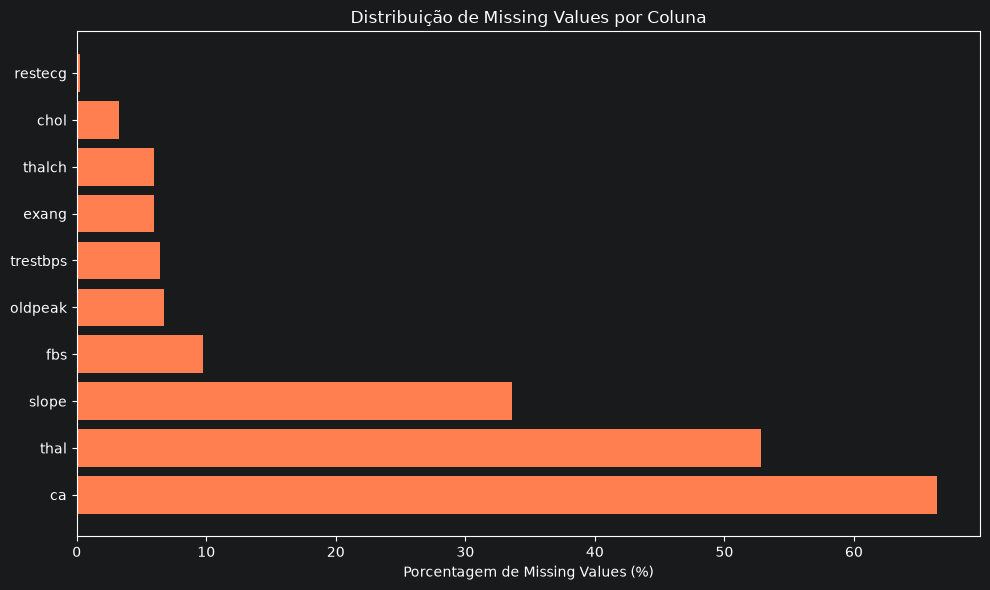

In [13]:
# Análise de valores ausentes
print("=== ANÁLISE DE MISSING VALUES ===\n")
missing_values = pd.DataFrame({
   'Coluna': df.columns,
   'Missing_Count': df.isnull().sum(),
   'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values(
   by='Missing_Percentage', ascending=False
)
if len(missing_values) > 0:
   print(missing_values)
   # Visualizar missing values
   plt.figure(figsize=(10, 6))
   plt.barh(missing_values['Coluna'], missing_values['Missing_Percentage'], color='coral')
   plt.xlabel('Porcentagem de Missing Values (%)')
   plt.title('Distribuição de Missing Values por Coluna')
   plt.tight_layout()
   plt.show()
else:
   print("Nenhum missing value detectado!")

=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===

Contagem:
target
1    509
0    411
Name: count, dtype: int64

Percentual:
Com doença (1): 55.33%
Sem doença (0): 44.67%


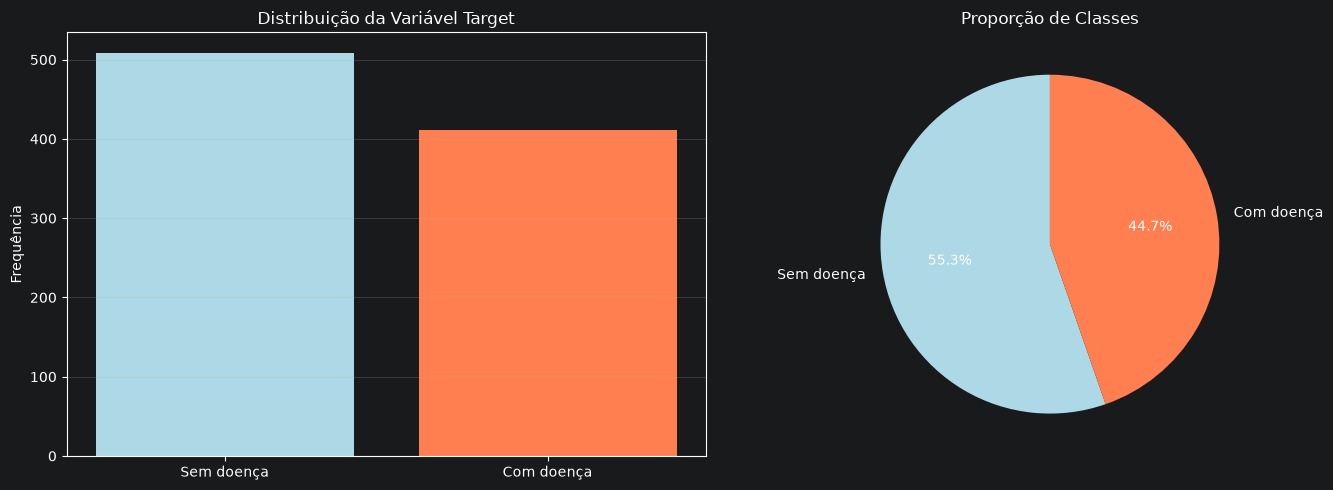


Ratio de balanceamento: 0.81
✓ Dataset razoavelmente balanceado.


In [9]:
# Renomear variável `num` para `target`
df.rename(columns={'num': 'target'}, inplace=True)
# Converter target para binário (0 = sem doença, 1 = com doença)
# No dataset original, valores > 0 indicam presença de doença
df['target'] = (df['target'] > 0).astype(int)

print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===\n")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True) * 100

print("Contagem:")
print(target_counts)

print("\nPercentual:")
for idx, pct in target_percentages.items():
   label = "Sem doença" if idx == 0 else "Com doença"
   print(f"{label} ({idx}): {pct:.2f}%")


# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(['Sem doença', 'Com doença'], target_counts.values, color=['lightblue', 'coral'])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Target')
axes[0].grid(axis='y', alpha=0.3)


# Gráfico de pizza
axes[1].pie(target_counts.values, labels=['Sem doença', 'Com doença'],
           autopct='%1.1f%%', colors=['lightblue', 'coral'], startangle=90)
axes[1].set_title('Proporção de Classes')
plt.tight_layout()
plt.show()

# Verificar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
   print("⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.")
else:
   print("✓ Dataset razoavelmente balanceado.")

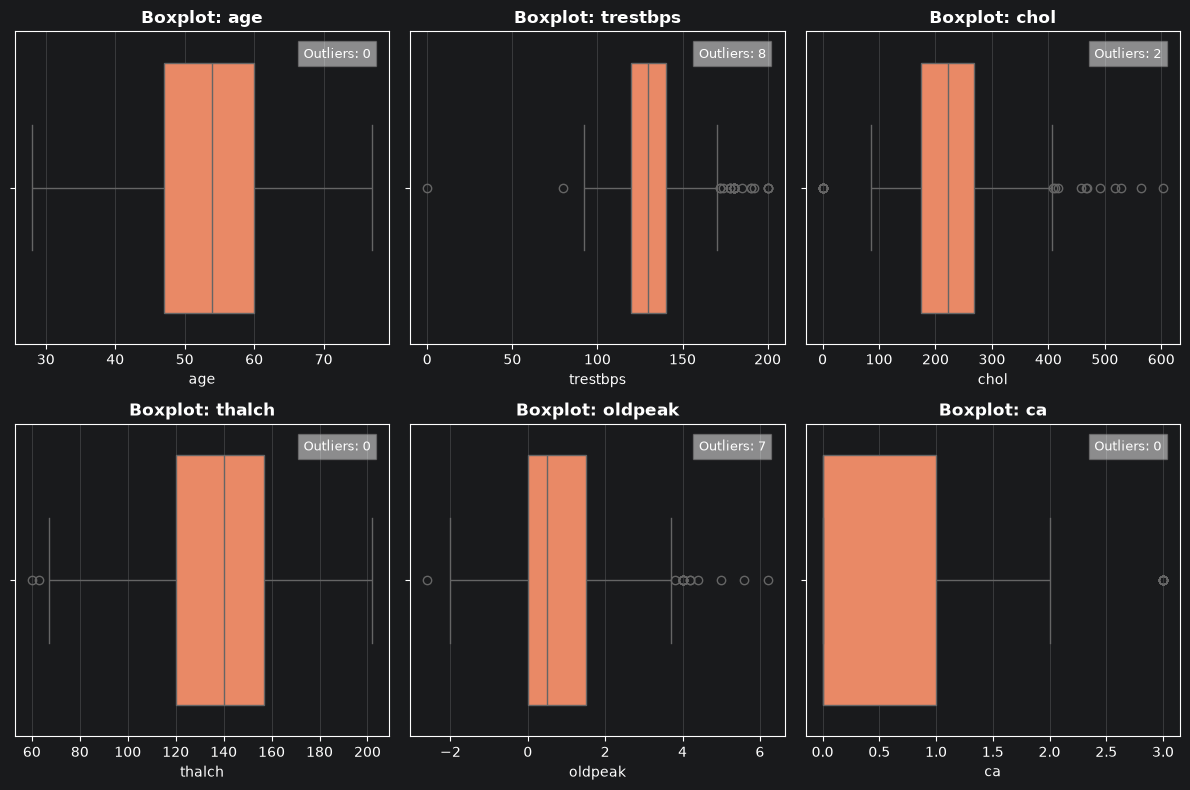

In [10]:
# Colunas numéricas (excluindo id e target)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['id', 'target'])

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}',
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()